In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Akshaya Chilka\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.drop('customerID', axis=1, inplace=True)

In [5]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df.dropna(inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [10]:
df.shape

(7032, 20)

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


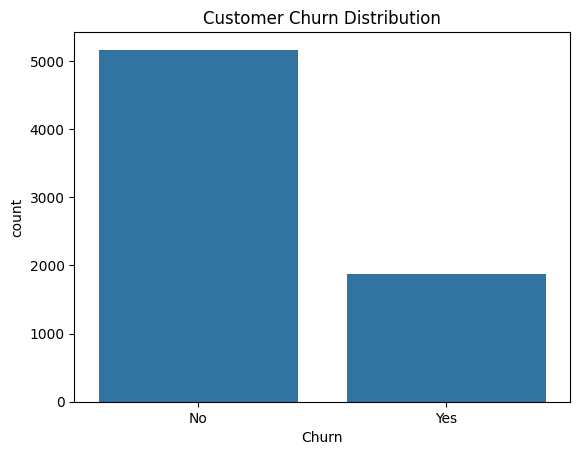

In [13]:
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

In [14]:
churn_rate = (df['Churn'].value_counts(normalize=True) * 100)

print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


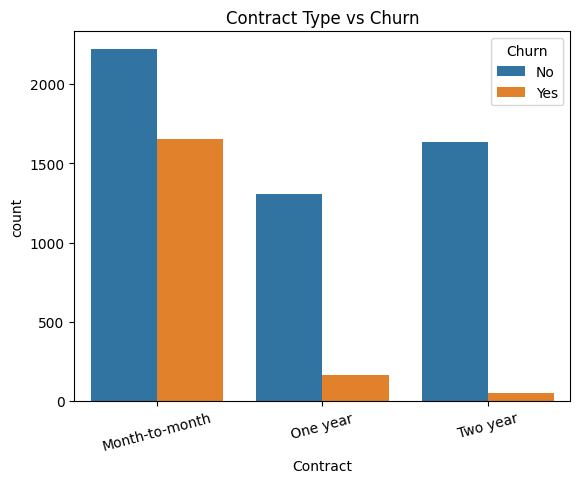

In [15]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=15)

plt.show()

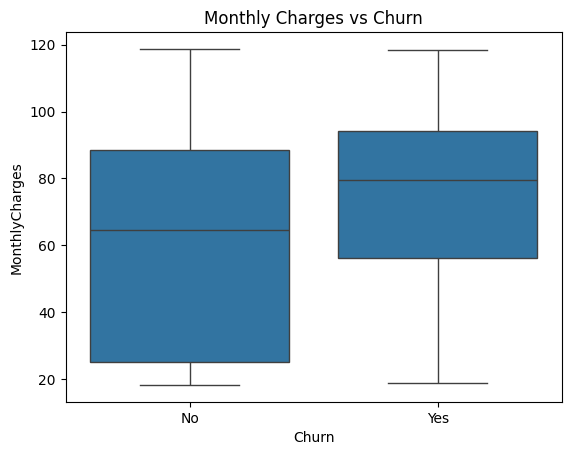

In [16]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

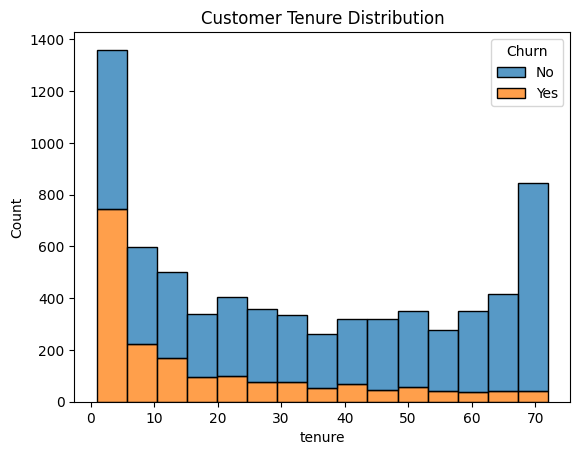

In [17]:
sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    multiple='stack'
)

plt.title("Customer Tenure Distribution")

plt.show()

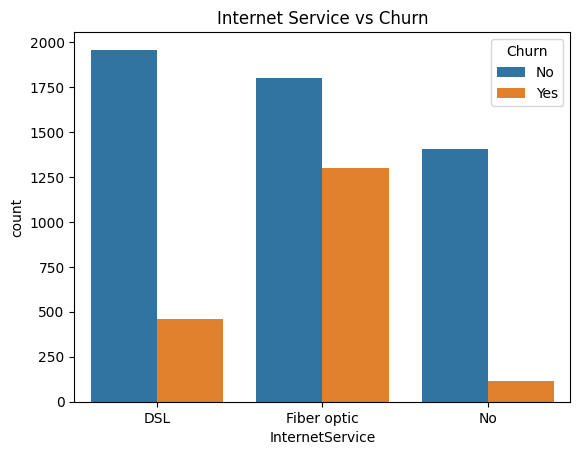

In [18]:
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title("Internet Service vs Churn")

plt.show()

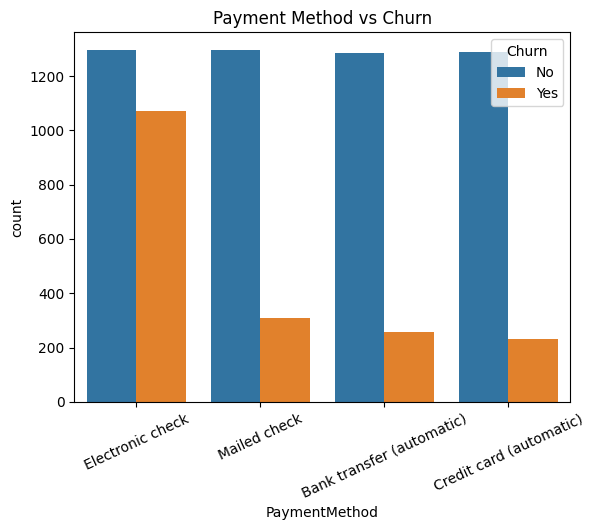

In [19]:
sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.title("Payment Method vs Churn")

plt.xticks(rotation=25)

plt.show()

In [20]:
import numpy as np

df['Risk_Level'] = np.where(
    df['tenure'] < 12,
    'High Risk',
    np.where(
        df['tenure'] < 24,
        'Medium Risk',
        'Low Risk'
    )
)

In [21]:
df.to_csv("FINAL_DASHBOARD_DATA.csv", index=False)